# Optimal Planning
This notebook demonstrates how to use differentiable physics simulation and nonlinear optimization to synthesize a throwing motion an object attached to a deformable linear object (DLO), such as a cable or flexible tube.

The system models a robotic gripper manipulating the dlo, accelerating it, and releasing it so that it follows a desired ballistic trajectory into a target bin.

The optimization problem is solved using the Levenberg–Marquardt (LM) algorithm together with the differentiability of AJX.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

## Settings

In [2]:

import jax.numpy as jnp
# Simulation settings
timestep = 0.016667
horizon = 60
extra_horizon = 60

# Environment settings
gravity = jnp.array([0.0, 0.0, -9.82])
nu = 0.333
youngs_modulus = 4e7
n_segments = 6
dlo_length = 0.3
outer_radius = 0.015
inner_radius = 0.013
dlo_density = 1000.0

# Optimization weights
coulomb_penalty_weight = 1e3
target_velocity_weight = 1.0
target_position_weight = 1.0
control_regularization_weight = 0.01
power_penalty_weight = 1.0
power_max = 500.0

friction_coefficient_eval = 0.5
friction_coefficient_constraint = 0.5

# Trajectory settings
flight_time = 0.5
target_pos = jnp.array([0.3, 0.0, 0.3])
bin_pos = jnp.array([0.8, 0.0, -0.1])

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Build environment

In [3]:
import jax
from ajx.example_environments.dlo_scoop import DLOScoop, DLOSettings, CableParameters
from ajx import SimulationSettings, Solver
from ajx import math
target_vel = (
        (bin_pos - target_pos) / flight_time
        - 0.5 * gravity * flight_time
    )
env = DLOScoop(
    sim_settings=SimulationSettings(
        timestep, True, Solver.DENSE_LINEAR
    ),
    env_settings=DLOSettings.create(
        n_segments=n_segments,
        length=dlo_length,
        outer_radius=outer_radius,
        inner_radius=inner_radius,
        density=dlo_density,
        pose_estimate_linear_offsets=[],
        loose_end=False,
    ),
    target_pos=target_pos,
    target_vel=target_vel,
    bin_pos=bin_pos,
)

env.camera_pos = jnp.array([0.5, -3.0, 0.0])
env.camera_rot = math.quat_from_axis_angle(jnp.array([0.0, 0.0, 1.0]), 0.0)

cable_param = CableParameters(
    youngs_modulus=youngs_modulus,
    shear_modulus=youngs_modulus / (2 * (1 + nu)),
    damping=env.default_param.sparse_param.cable_param.damping,
)
env_param = env.default_param.tree_replace(
    src={"sparse_param.cable_param": cable_param}
)
initial_state = env.get_neutral_state(env_param)

## Residual functions

In [4]:
def get_robot_power(state, env, env_param, timestep):
    """Estimate the total mechanical power produced by the robot joints."""
    # There are three constraint for yaw-pitch-roll control.
    link_multipliers = state.multipliers.reshape(-1, 6)[:3]

    # Select the active joint components for the three link constraints.
    pos_yaw_degrees = jnp.array([0, 1, 2, 5])
    hinge_degree = jnp.array([5])
    pos_yaw_multipliers = link_multipliers[0, pos_yaw_degrees]
    pitch_multipliers = link_multipliers[1, hinge_degree]
    roll_multipliers = link_multipliers[2, hinge_degree]

    # Map the constraint multipliers into generalized forces at each joint.
    G1 = env.lock_world_to_hidden1a.object_jacobian(state, env_param)
    f1 = G1.reshape(6, 6)[pos_yaw_degrees].T @ pos_yaw_multipliers / timestep

    G2 = env.lock_hidden1a_to_hidden2a.object_jacobian(state, env_param)
    G2_prime = G2.reshape(2, 6, 6)[:, hinge_degree].transpose(0, 2, 1)
    f2 = G2_prime @ pitch_multipliers / timestep

    G3 = env.lock_hidden2a_to_gripper1.object_jacobian(state, env_param)
    G3_prime = G3.reshape(2, 6, 6)[:, hinge_degree].transpose(0, 2, 1)
    # Convert impulse-like quantities to forces using the timestep.
    f3 = G3_prime @ roll_multipliers / timestep

    # Power is force/torque dotted with the corresponding generalized velocity.
    P1 = jnp.dot(f1, state.gvel.data[0])
    P2_1 = jnp.dot(f2[0], state.gvel.data[0])
    P2_2 = jnp.dot(f2[1], state.gvel.data[1])
    P3_1 = jnp.dot(f3[0], state.gvel.data[1])
    P3_2 = jnp.dot(f3[1], state.gvel.data[2])
    return P1 + P2_1 + P2_2 + P3_1 + P3_2

def get_object_normal_multiplier(state):
    cylinder_lock_mul = state.multipliers[-6:]
    lambda_n = -cylinder_lock_mul[2]
    return lambda_n

def get_object_tangent_multipliers(state):
    cylinder_lock_mul = state.multipliers[-6:]
    lambda_t = cylinder_lock_mul[:2]
    return lambda_t

def power_limit_residual(state, env, env_param, timestep, max_power, penalty_weight):
    """Return a penalty when robot power exceeds the configured limit."""
    total_power = get_robot_power(state, env, env_param, timestep)
    return penalty_weight * jnp.maximum(0.0, total_power - max_power)

def coulomb_limit_penalty(state, friction_coefficient, penalty_weight):
    """
    Return residual penalties for violating the contact friction model.
    """
    # Extract the normal force and the 2D tangential force components.
    lambda_t = get_object_tangent_multipliers(state)
    lambda_n = get_object_normal_multiplier(state)

    # Penalize excessive tangential force relative to the allowed
    # friction cone defined by the supplied friction coefficient.
    lambda_t_norm = jnp.linalg.norm(lambda_t)
    coulomb_residual = penalty_weight * jnp.maximum(
        0.0, -lambda_t_norm + friction_coefficient * lambda_n
    )

    # Also penalize positive normal multiplier values so the optimizer
    # prefers the expected sign convention for the contact constraint.
    positive_normal_residual = penalty_weight * jnp.maximum(0.0, -lambda_n)

    return jnp.concatenate([coulomb_residual, positive_normal_residual], axis=None)

@jax.jit
def residuals(control_signal):
    control_signal = control_signal.reshape([horizon, 6])
    per_step_residuals0 = jnp.zeros((horizon, 3))

    def body_fn(i, carry):
        state, per_step_residuals = carry
        state = env.step_state(state, control_signal[i], env_param)

        contact_residual = coulomb_limit_penalty(
            state,
            friction_coefficient=friction_coefficient_constraint,
            penalty_weight=coulomb_penalty_weight,
        )
        power_residual = power_limit_residual(
            state,
            env,
            env_param,
            timestep,
            max_power=power_max,
            penalty_weight=power_penalty_weight,
        )
        step_residual = jnp.concatenate(
            [contact_residual, jnp.atleast_1d(power_residual)]
        )
        per_step_residuals = per_step_residuals.at[i].set(step_residual)
        return state, per_step_residuals

    final_state, per_step_residuals = jax.lax.fori_loop(
        0,
        horizon,
        body_fn,
        (initial_state, per_step_residuals0),
    )

    terminal_velocity_error = (
        target_velocity_weight
        * (final_state.gvel.data[-1, :3] - target_vel)
    )
    terminal_position_error = (
        target_position_weight
        * (final_state.conf.pos[-1, :3] - target_pos)
    )
    control_regularization = (
        control_signal * control_regularization_weight
    )

    return jnp.concatenate(
        [
            per_step_residuals,
            terminal_velocity_error,
            terminal_position_error,
            control_regularization,
        ],
        axis=None,
    ).flatten()


## Optimization loop
Use `scipy.least_squares` to attempt to find a solution to the planning problem.

In [5]:
from jax import jacfwd
from scipy.optimize import least_squares

control_signal = jnp.ones([horizon, 6]).flatten()

res = least_squares(
    fun=residuals,
    jac=jacfwd(residuals),
    x0=control_signal,
    method="trf",
    max_nfev=250,
    xtol=None,
    verbose=2,
)


solution = res.x.reshape([horizon, 6])

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.1991e+02                                    2.55e+03    
       1              2         5.8394e+02      3.36e+02       1.90e+01       4.33e+02    
       2              4         3.2447e+01      5.51e+02       1.18e+00       1.54e+02    
       3              6         3.1903e+00      2.93e+01       5.89e-01       9.21e+01    
       4              8         1.4071e+00      1.78e+00       2.94e-01       2.41e+01    
       5              9         6.4466e-01      7.62e-01       2.94e-01       2.50e+01    
       6             11         3.5012e-01      2.95e-01       7.36e-02       1.70e+01    
       7             12         3.3390e-01      1.62e-02       7.36e-02       1.29e+01    
       8             13         5.9671e-02      2.74e-01       1.84e-02       6.35e+00    
       9             14         6.6862e-03      5.30e-02       3.68e-02       2.08e+00    

/home/hannes/repos/ajx_copies/AJX/.venv/lib/python3.14/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: overflow encountered in power
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm
/home/hannes/repos/ajx_copies/AJX/.venv/lib/python3.14/site-packages/scipy/optimize/_lsq/common.py:154: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = phi / phi_prime
/home/hannes/repos/ajx_copies/AJX/.venv/lib/python3.14/site-packages/scipy/optimize/_lsq/common.py:166: RuntimeWarning: divide by zero encountered in scalar divide
  p *= Delta / norm(p)
/home/hannes/repos/ajx_copies/AJX/.venv/lib/python3.14/site-packages/scipy/optimize/_lsq/common.py:166: RuntimeWarning: invalid value encountered in multiply
  p *= Delta / norm(p)
/home/hannes/repos/ajx_copies/AJX/.venv/lib/python3.14/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: invalid value encountered in scalar divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm


      15             250        3.0508e-03      0.00e+00       0.00e+00       3.17e-01    
The maximum number of function evaluations is exceeded.
Function evaluations 250, initial cost 9.1991e+02, final cost 3.0508e-03, first-order optimality 3.17e-01.


## Render solution

In [6]:
from panda3d.core import loadPrcFileData

loadPrcFileData("", "window-type offscreen")
loadPrcFileData("", "win-size 640 480")

from ajx.example_graphics.environment_scene import EnvironmentScene
from ajx.example_graphics.application import Application
render_fps = 60
env_step = jax.jit(env.step)
state = initial_state
if "scene" in locals():
    del scene
scene = EnvironmentScene(
    env,
    env_param,
    initial_state,
    show_text=False,
    show_fps=False,
    debug_render=False,
)
if "app" in locals():
    app.destroy()
    del app
app = Application(scene, render_fps, "default", headless=True)

Known pipe types:
  glxGraphicsPipe
(1 aux display modules not yet loaded.)


In [ ]:
import imageio
from IPython.display import Video
import numpy as np

output_path = "animation.mp4"
power = np.zeros(horizon+extra_horizon)
normal_force = np.zeros(horizon+extra_horizon)
tangent_force = np.zeros(horizon+extra_horizon)

writer = imageio.get_writer(output_path, fps=render_fps)

control_data = solution
control_data = jnp.concatenate(
    [control_data, jnp.zeros_like(control_data[-1])[None]]
)

def released_cylinder_param(env_param):
    return env_param.tree_replace(
        {"constraint_param.compliance.lock_gripper2_to_cylinder": jnp.full((6,), 1e8)},
    )


active_env_param = env_param
for i in range(horizon + extra_horizon):
    if i == horizon:
        # Release the cylinder at the release time-step
        active_env_param = released_cylinder_param(active_env_param)

    # Step physics
    state, _observations = env_step(state, control_data[i], active_env_param)

    # Store variables
    normal_force[i] = get_object_normal_multiplier(state)
    tangent_force[i] = jnp.linalg.norm(get_object_tangent_multipliers(state))
    power[i] = get_robot_power(state, env, active_env_param, timestep)

    # Render frame
    scene.state = state
    scene.update_geometry()
    app.graphicsEngine.renderFrame()
    frame = app.get_headless_frame()
    writer.append_data(np.array(frame))

writer.close()
Video(output_path)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
/usr/lib/python3.14/subprocess.py:1919: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


## Create plots

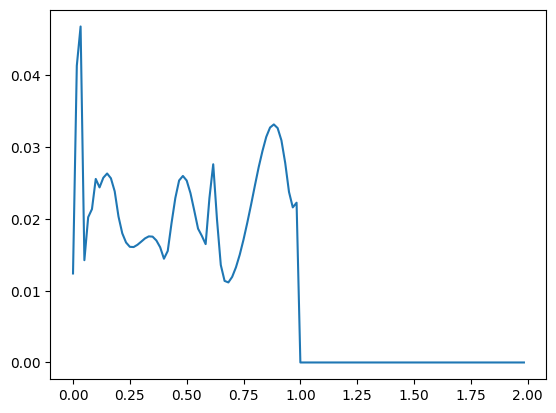

In [ ]:
import matplotlib.pyplot as plt

time = np.arange(horizon+extra_horizon)*timestep
plt.plot(time, normal_force)
plt.plot(time, tangent_force)

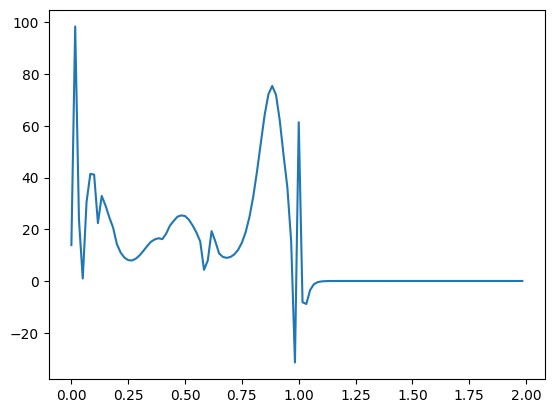

In [ ]:
plt.plot(time, power)